# VIP analysis

In [3]:
%load_ext autoreload
%load_ext usnm2p.skip_kernel_extension
%autoreload 2

## Imports

In [4]:
# External packages
import os
import jupyter_slack
import datetime
from statannotations.Annotator import Annotator

# Internal modules
from usnm2p.logger import logger
from usnm2p.constants import *
from usnm2p.utils import *
from usnm2p.indexers import *
from usnm2p.fileops import *
from usnm2p.postpro import *
from usnm2p.plotters import *
from usnm2p.batchutils import *
from usnm2p.parsers import extract_FOV_area, resolve_mouseline, parse_date_mouse_region

# Figures dictionary
figs = {}

## Parameters

### Input datasets and main processing parameters

In [5]:
# Processing parameters
analysis_type = 'main'  # Analysis type
mouseline = 'cre_vip'  # mouse line
layer = None  # cortical layer
slack_notify = False
global_correction = GLOBAL_CORRECTION  # global stack correction method
kalman_gain = KALMAN_GAIN  # gain of Kalman filter
gcamp_key = get_gcamp_key(mouseline)  # GCaMP channel key
neuropil_scaling_coeff = NEUROPIL_SCALING_COEFF  # scaling coefficient for neuropil subtraction
baseline_quantile = BASELINE_QUANTILE  # evaluation quantile for baseline computation
baseline_wquantile = BASELINE_WQUANTILE  # quantile filter window size (s) to compute fluorescence baseline
baseline_wsmoothing = BASELINE_WSMOOTHING  # gaussian filter window size (s) to smooth out fluorescence baseline
trial_aggfunc = TRIAL_AGGFUNC  # trial aggregation function
ykey_classification = YKEY_CLASSIFICATION  # Reference variable for response classification
directional = True  # whether to look for directional (i.e. positive only) effect for response detection

# Plotting parameters
xkeys_plt = [  # input parameters
    Label.P,
    Label.DC,
    Label.ISPTA
]
ykey_plt = Label.ZSCORE  # plotting variable

### Derived parameters

In [6]:
# If global correction is dictionary, extract line-specific method
if isinstance(global_correction, dict):
    global_correction = global_correction[mouseline]

# Get batch-related settings
dataset_group_id, input_dir, figsdir, figs_suffix = get_batch_settings(
    analysis_type, mouseline, layer, global_correction, kalman_gain, neuropil_scaling_coeff,
    baseline_quantile, baseline_wquantile, baseline_wsmoothing,
    trial_aggfunc, ykey_classification, directional)
baseline_id = get_baseline_id(baseline_quantile, baseline_wquantile, baseline_wsmoothing)

ispv = mouseline == 'pv'
isnotpv = not ispv

# Resolve red channel name
red_channel_key = mouseline.split('_')[1].upper()

# Get time stamp from notebook start
tstamp_start = datetime.datetime.now()
fmts = ['%Y-%m-%d', '%H:%M:%S']
# Log start process
s = f'{dataset_group_id} {analysis_type} analysis notebook started on {tstamp_start.strftime(fmts[0])} at {tstamp_start.strftime(fmts[1])}'
if slack_notify:
    jupyter_slack.notify_self(s)
logger.info(s)

 2026/02/23 11:51:55: assembling batch analysis settings...
 2026/02/23 11:51:55: cre_vip main analysis notebook started on 2026-02-23 at 11:51:55


### Input summary table figure

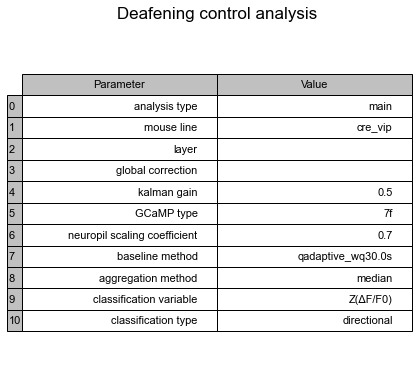

In [7]:
figs['dataset_info'] = plot_table({
    'analysis type': analysis_type,
    'mouse line': mouseline,
    'layer': layer,
    'global correction': global_correction,
    'kalman gain': kalman_gain,
    'GCaMP type': gcamp_key,
    'neuropil scaling coefficient': neuropil_scaling_coeff,
    'baseline method': baseline_id,
    'aggregation method': trial_aggfunc.__name__,
    'classification variable': ykey_classification,
    'classification type': f"{'' if directional else 'non '}directional",
    }, title='Deafening control analysis', aspect=1.5)

## Load & inspect initial data

### Load data

In [8]:
# Determine what to do in case of duplicate runs
on_duplicate_runs = 'drop_last'

# Load datasets
logger.info(f'loading data from {input_dir}:')
data = load_processed_datasets(
    input_dir, layer=layer,
    exclude_patterns=None,
    on_duplicate_runs=on_duplicate_runs)
logger.info('data successfully loaded.')

# Parse dates, mice and regions from datasets
datasets = data[list(data.keys())[0]].index.unique(level=Label.DATASET).tolist()
datasets_info = parse_date_mouse_region(datasets)
datasets

 2026/02/23 11:51:55: loading data from /Users/tlemaire/Documents/data/usnm/processed/aggmedian_classzscore_directional/alpha0.7_qadaptive_wq30.0s/suite2p_fs_5.0_nchannels_2_reg_tif_reg_tif_chan2_tau_0.7/kd_G0.5_V0.05_npad10/submap_stim-1->stimeverytrial/30.0Hz_5.0Hz_smooth/main/cre_vip:
 2026/02/23 11:51:55: gathering dataset IDs...
 2026/02/23 11:51:55: loading mouse-region data from 20200305_mouse212_region1.h5
 2026/02/23 11:51:55: loading mouse-region data from 20200309_mouse214_region1.h5
 2026/02/23 11:51:55: assembling data structures...
 2026/02/23 11:51:56: harmonizing run index by param across datasets
 2026/02/23 11:51:56: generating expanded conditions...
 2026/02/23 11:51:56: expanding "triagg_stats" condition to match "trialagg_timeseries" timeseries
 2026/02/23 11:51:56: expanding "stats" condition w/o. ['ROI'] dimensions to match "popagg_timeseries" timeseries
 2026/02/23 11:51:56: updating trialagg_timeseries run index
 2026/02/23 11:51:56: updating popagg_timeseries 

['20200305_mouse212_region1', '20200309_mouse214_region1']

### Unpack data and get ROI counts

In [9]:
# Unpack
trialagg_timeseries, popagg_timeseries, trialagg_stats, ext_stats, ROI_masks, map_ops = extract_from_batch_data(data)

# Extract number of frames per trial from timeseries multi-index
nframes_per_trial = popagg_timeseries.index.unique(level=Label.FRAME).max() + 1

# Assemble frame indexer object
tref = get_stim_onset_time(mouseline)
fps = get_singleton(trialagg_stats, Label.FPS)
fidx = FrameIndexer.from_time(tref, TPRE, TPOST, 1 / fps, npertrial=nframes_per_trial)

# Display ROI count per dataset & run, and highlight incomplete datasets
logger.info('detailed ROI count:')
get_detailed_ROI_count(trialagg_stats, style=True)

 2026/02/23 11:51:56: extracting timeseries and stats from data...
 2026/02/23 11:51:57: detailed ROI count:


run,0,1,2,3,4,5,6,7,8,9,10
P (MPa),0.00,0.10,0.20,0.40,0.60,0.80,0.80,0.80,0.80,0.80,0.80
DC (%),50,50,50,50,50,05,10,20,30,40,50
dataset,,,,,,,,,,,
20200305_mouse212_region1,nan,nan,202,202,202,nan,nan,nan,nan,nan,202
20200309_mouse214_region1,234,234,234,234,234,234,234,234,234,234,234


In [25]:
ROI_masks

ypix  xpix       lam
dataset                   ROI                      
20200305_mouse212_region1 0     152   110  0.164798
                          0     153   107  0.221136
                          0     153   108  0.309534
                          0     153   109  0.357020
                          0     153   110  0.362753
...                             ...   ...       ...
20200309_mouse214_region1 728   373   356  0.100680
                          728   374   351  0.137956
                          728   374   352  0.164346
                          728   374   353  0.188417
                          728   374   354  0.115292

[80591 rows x 3 columns]

In [ ]:
for k, ops in map_ops.items():
    print(k)

# intensity_ratio(ops, stats)

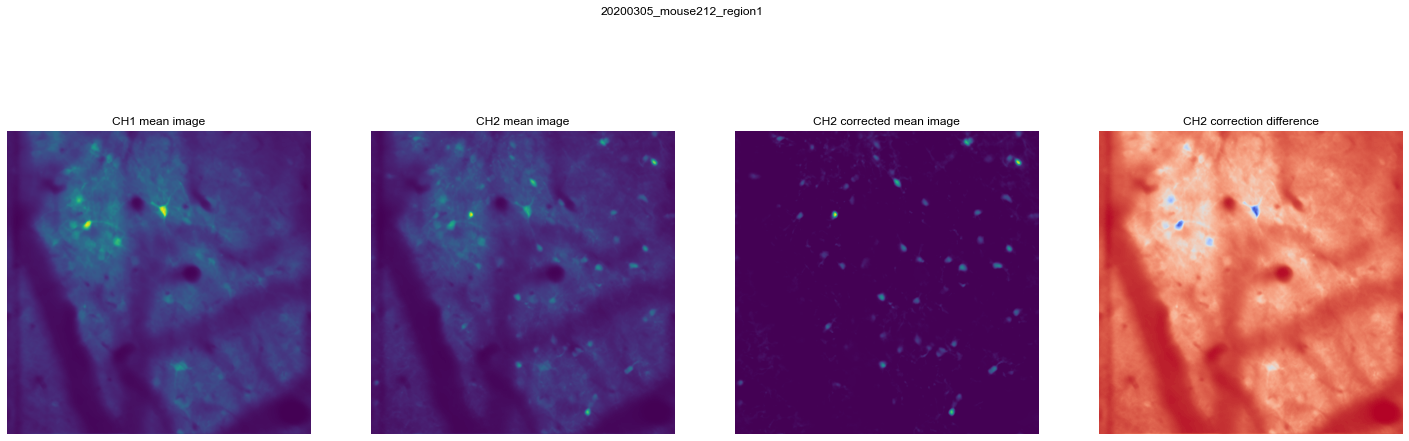

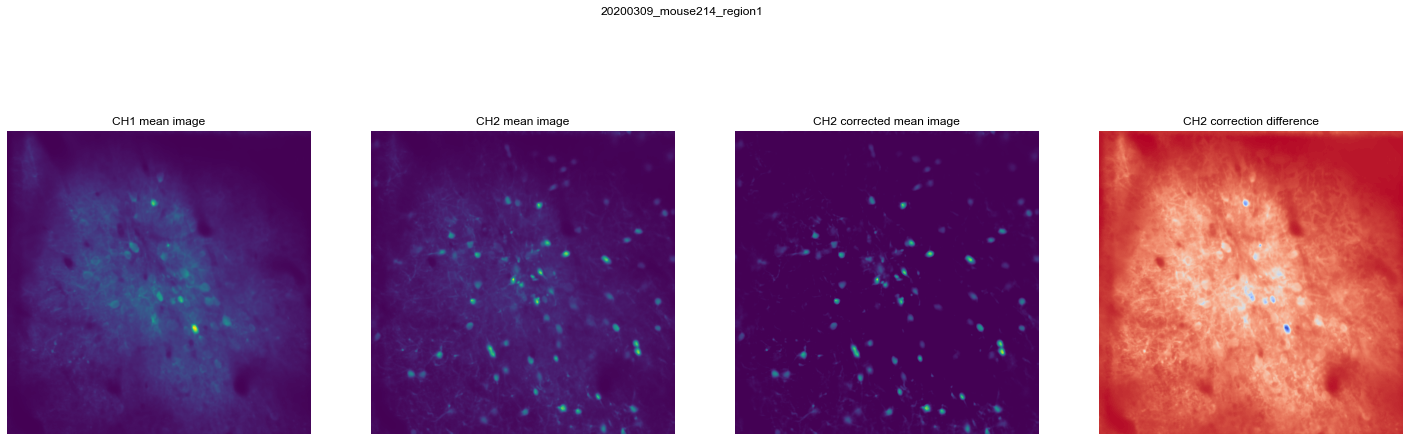

In [27]:
for k, ops in map_ops.items():
    fig, axes = plt.subplots(1, 4, figsize=(25,8))
    axiter = iter(axes)
    ax = next(axiter)
    ax.imshow(map_ops[k]['meanImg'])
    ax.set_title('CH1 mean image')
    ax = next(axiter)
    ax.imshow(map_ops[k]['meanImg_chan2'])
    ax.set_title('CH2 mean image')
    ax = next(axiter)
    ax.imshow(map_ops[k]['meanImg_chan2_corrected'])
    ax.set_title('CH2 corrected mean image')
    ax = next(axiter)
    ax.imshow(map_ops[k]['meanImg_chan2_corrected'] - map_ops[k]['meanImg_chan2'], cmap='coolwarm')
    ax.set_title('CH2 correction difference')
    for ax in axes:
        ax.axis('off')
    fig.suptitle(k)

### Extract red vs non-red cells

 2025/12/05 16:04:11: extracting CH2 cells stats ...


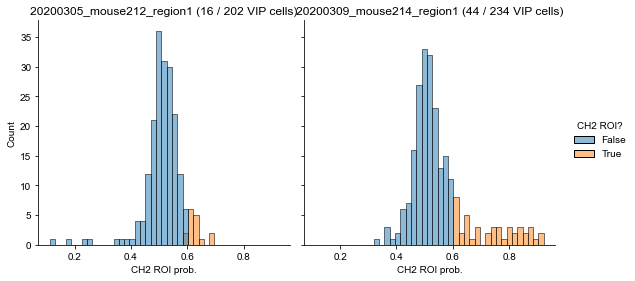

In [8]:
# Extracting cells "CH2" stats
logger.info('extracting CH2 cells stats ...')
coreg_stats = (
    trialagg_stats[[Label.CH2_ROI_PROB, Label.CH2_ROI]]
    .groupby([Label.DATASET, Label.ROI], sort=False)
    .first()
)

# Identify red channel cells by thresholding ROI-overlaps between CH1 and CH2
overlap_thr = 0.6
coreg_stats[Label.CH2_ROI] = coreg_stats[Label.CH2_ROI_PROB] > overlap_thr
counts = (
    coreg_stats[Label.CH2_ROI]
    .groupby(Label.DATASET, sort=False)
    .agg(['sum', 'size'])
    .rename(columns={'sum': red_channel_key, 'size': 'total'})
)
g = sns.displot(
    data=coreg_stats,
    x=Label.CH2_ROI_PROB,
    col=Label.DATASET,
    hue=Label.CH2_ROI,
    height=4
)
for k, ax in g.axes_dict.items():
    ax.set_title(f'{k} ({counts.loc[k, red_channel_key]} / {counts.loc[k, "total"]} {red_channel_key} cells)')
figs['coreg probs'] = g.fig

# Add co-registered cells information to data
trialagg_stats[Label.CH2_ROI] = coreg_stats[Label.CH2_ROI]
ext_stats[Label.CH2_ROI] = coreg_stats[Label.CH2_ROI]
trialagg_timeseries[Label.CH2_ROI] = coreg_stats[Label.CH2_ROI]

### Inspect cell maps

 2026/02/24 14:41:31: sorted cell densities:
dataset
20200305_mouse212_region1    770.568848
20200309_mouse214_region1    892.639160
dtype: float64
 2026/02/24 14:41:31: plotting cell maps...


100%|██████████| 2/2 [00:02<00:00,  1.42s/it]


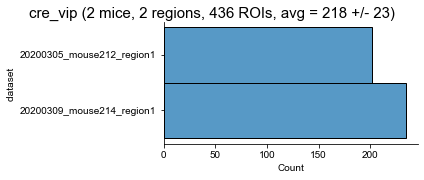

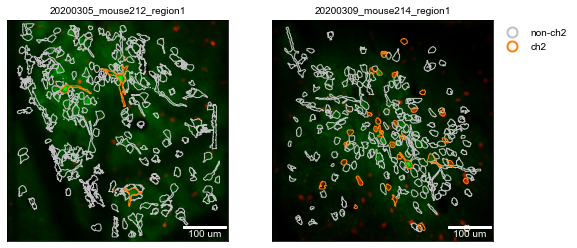

In [26]:
figs['cellcounts'] = plot_cellcounts(trialagg_stats, hue=None, title=mouseline)

# Compute ROI density for each dataset
FOV_areas = pd.Series({k: extract_FOV_area(v) for k, v in map_ops.items()})  # mm2
ROI_counts = get_detailed_ROI_count(trialagg_stats).max(axis=1).astype(int)  # cells
ROI_densities = ROI_counts / FOV_areas  # cells/mm2
logger.info(f'sorted cell densities:\n{ROI_densities.sort_values()}')

# Plot cell maps and highlight outlier datasets
figs['cellmaps'] = plot_fields_of_view(
    map_ops, 
    # refkey='max_proj',
    ROI_masks=ROI_masks, 
    Fstats=trialagg_stats,
    hue=Label.CH2_ROI, # None
    mode='contour', 
    qmax=.999,
    height=5,
)

### Inspect baseline variation throughout experiments and exclude outlier datasets

 2025/12/05 16:04:14: inspecting relative variations in baseline fluorescence across experiments...


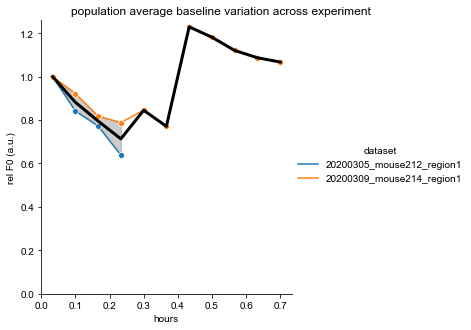

In [10]:
runid_maps = trialagg_stats[Label.RUNID].groupby([Label.DATASET, Label.RUN]).first()

def get_rel_F0(data, F0_key=Label.F0, aggbyrun=True):
    ''' Extract temporal evolution of F0 over experiment '''
    # Figure out dataset ID and associated run order
    dataset_id = data.index.unique(Label.DATASET)[0]
    # Add time along entire experiment to population-average dataframe average
    idx = get_index_along_experiment(data.index, runid_map=runid_maps.loc[dataset_id])
    data[Label.TIME] = idx / fps
    # If specified, aggregate by run
    if aggbyrun:
        data = data.groupby(Label.RUN).median()
    # Compute relative variation from max
    yref = data.sort_values(Label.TIME)[F0_key].iloc[0]
    # yref = data[F0_key].max()
    relF0_key = f'rel {F0_key}'
    data[relF0_key] = data[F0_key] / yref
    # Return data of interest
    return data[[Label.TIME, relF0_key]]

# Compute relative variation of average baseline along experiment, for each dataset
logger.info('inspecting relative variations in baseline fluorescence across experiments...')
aggbyrun = True
F0_key = Label.F0
relF0_key = f'rel {F0_key}'
popagg_F0_per_run = (
    popagg_timeseries
    .groupby(Label.DATASET)
    .apply(lambda x: get_rel_F0(x, F0_key=F0_key, aggbyrun=aggbyrun))
)
popagg_F0_per_run[Label.HOURS] = popagg_F0_per_run[Label.TIME] / 3600

# Plot time evolution of average baseline along experiment, for each dataset
pltkwargs = dict(
    x=Label.HOURS,
    y=relF0_key,
)
fg = sns.relplot(
    kind='line',
    data=popagg_F0_per_run,
    errorbar=None, 
    hue=Label.DATASET,
    # hue_order=hue_order,
    marker='o',
    # palette=Palette.DEAFENING,
    aspect=1.,
    height=3 if not aggbyrun else 4.5,
    col=Label.DATASET if not aggbyrun else None,
    col_wrap=4 if not aggbyrun else None,
    **pltkwargs,
)
sns.despine(fig=fg.figure)
figs['popavg F0 across experiment'] = fg.figure
fg.figure.suptitle('population average baseline variation across experiment', y=1.01)
for ax in fg.figure.axes:
    ax.set_ylim(0, ax.get_ylim()[1])
if aggbyrun:
    # Add average trace across valid datasets
    sns.lineplot(
        ax=ax,
        data=popagg_F0_per_run,
        lw=3, 
        color='k',
        legend=False,
        **pltkwargs
    )

## Response curves

### Plot trial heatmap per condition for entire mouse line

 2025/12/05 16:04:15: 20200305_mouse212_region1: expanding 60600-rows series into 202 ROIs x 11 runs x 75 frames (166650-rows) series (106050 additional rows)
 2025/12/05 16:04:15: 20200309_mouse214_region1: original 193050-rows series is already rectilinear -> ignoring
 2025/12/05 16:04:15: adding time info to table...
 2025/12/05 16:04:15: plotting Z(ΔF/F0) trial heatmaps...


11it [00:02,  5.26it/s]                        


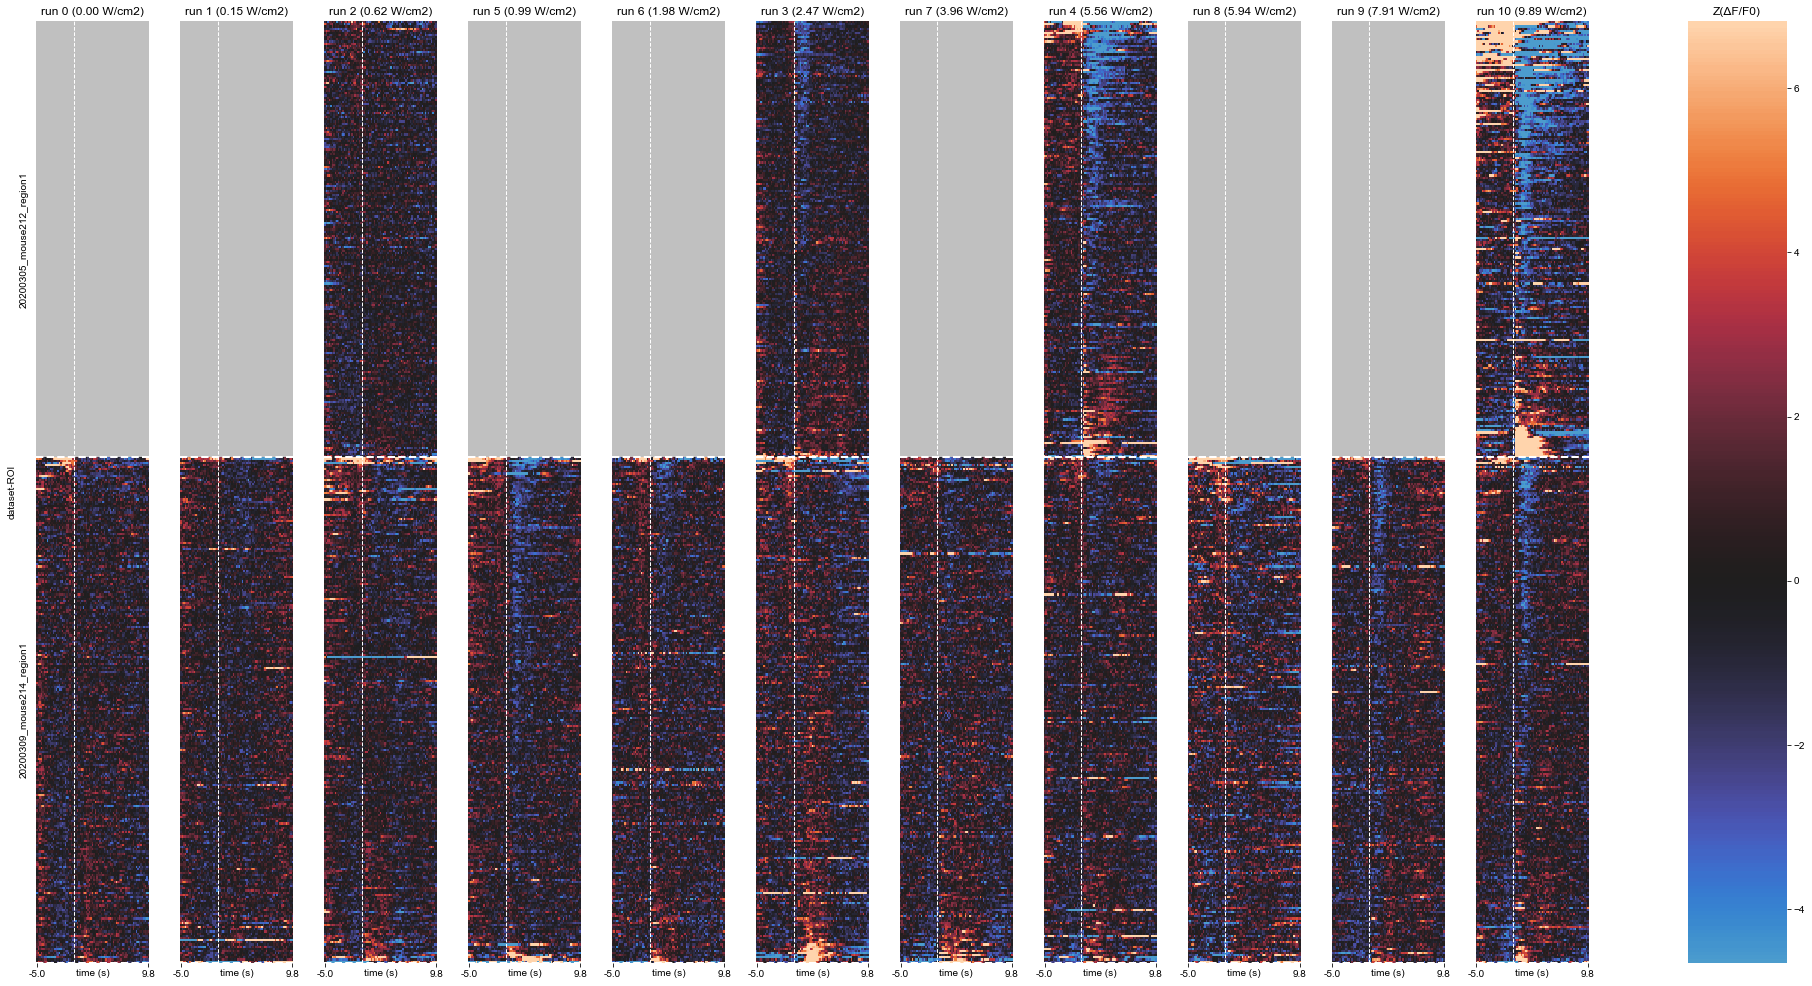

In [11]:
sorted_ISPTAs = (trialagg_stats[Label.ISPTA]
    .groupby(Label.RUN)
    .first()
    .sort_values()
    .apply('{:.2f} W/cm2'.format)
)

figs[f'{ykey_plt} heatmap'] = plot_activity_heatmap(
    trialagg_timeseries, ykey_plt, fidx, fps, col=Label.RUN,
    col_order=sorted_ISPTAs.index.values, 
    col_labels=sorted_ISPTAs.values,
    rasterized=True,
    colwrap=len(sorted_ISPTAs), 
    sort_ROIs=True,
    height_factor=3,
)

### Plot trial heatmap per condition for putative VIP cells

 2025/12/05 16:04:18: extracting data for cells identified in red channel ...
 2025/12/05 16:04:18: 20200305_mouse212_region1: expanding 4800-rows series into 16 ROIs x 11 runs x 75 frames (13200-rows) series (8400 additional rows)
 2025/12/05 16:04:18: 20200309_mouse214_region1: original 36300-rows series is already rectilinear -> ignoring
 2025/12/05 16:04:18: adding time info to table...
 2025/12/05 16:04:19: plotting Z(ΔF/F0) trial heatmaps...


11it [00:01,  8.47it/s]                        


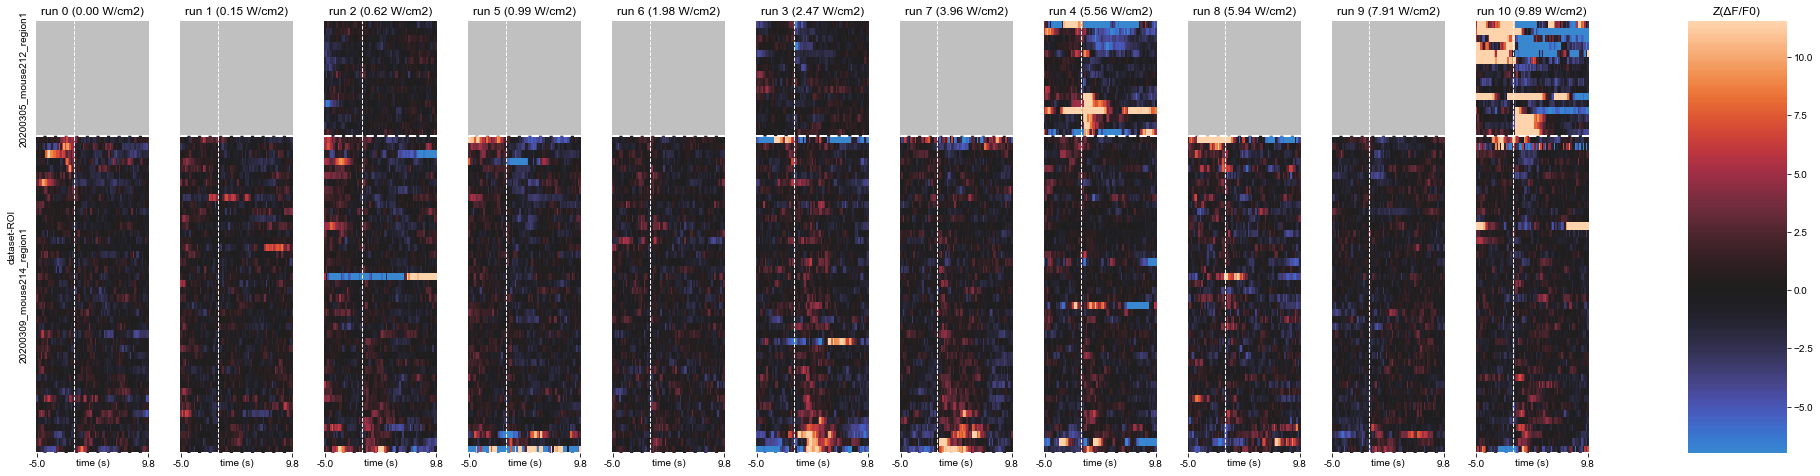

In [12]:
# Extracting data for cells co-registred in red channel
logger.info('extracting data for cells identified in red channel ...')
coreg_trialagg_stats = trialagg_stats[trialagg_stats[Label.CH2_ROI]]
coreg_ext_stats = ext_stats[ext_stats[Label.CH2_ROI]]
coreg_trialagg_timeseries = trialagg_timeseries[trialagg_timeseries[Label.CH2_ROI]]

figs[f'{ykey_plt} heatmap ch2'] = plot_activity_heatmap(
    coreg_trialagg_timeseries, ykey_plt, fidx, fps, col=Label.RUN,
    col_order=sorted_ISPTAs.index.values, 
    col_labels=sorted_ISPTAs.values,
    rasterized=True,
    colwrap=len(sorted_ISPTAs), 
    sort_ROIs=True,
    height_factor=10,
)

### Plot aggregate response trace for all common non-zero conditions, and identify temporal response features and corresponding response analysis window

In [21]:
# Add critical stats columns to timeseries data
plt_data = get_plot_data(
    trialagg_timeseries,
    trialagg_stats,
    fidx
)

# # ndatasets_per_run = plt_data.groupby(Label.RUN).agg(lambda df: len(df.index.unique(Label.DATASET))).iloc[:, 0]
# # iruns_with_complete_data = ndatasets_per_run[(ndatasets_per_run == ndatasets_per_run.max())].index
# # print(iruns_with_complete_data)
# # plt_data = plt_data.loc[pd.IndexSlice[:, iruns_with_complete_data], :]

# Variable of interest
ykey = Label.ZSCORE

# # Extract plot data for all conditions above ISPTA threshold
# logger.info(f'restricting data to conditions above ISPTA threshold ({ISPTA_THR} W/cm2)...')
# stim_pltdata = plt_data[plt_data[Label.ISPTA] > ISPTA_THR]

# # Plot average trace across datasets
# logger.info(f'plotting {ykey} response traces...')
# figs[f'{ykey} resp trace merged'], ax = plt.subplots(figsize=(5, 4))
# sns.despine(ax=ax)
# sns.lineplot(
#     ax=ax,
#     data=stim_pltdata,
#     x=Label.TIME,
#     y=ykey,
#     errorbar='se',
#     hue=Label.DATASET,
#     style=Label.CH2_ROI
# )
# sns.lineplot(
#     ax=ax,
#     data=stim_pltdata,
#     x=Label.TIME,
#     y=ykey,
#     errorbar='se',
#     color='k',
#     style=Label.CH2_ROI
# )
# ax.axvline(0, ls='--', c='k')
# ax.set_title(f'{ykey} across all stim conditions - full data', y=1.05)

# # Compute and materialize peak features on average trace
# logger.info('computing peak features on average trace...')
# s = stim_pltdata[ykey].groupby(Label.FRAME).mean()
# props = find_response_peak(
#     s.loc[fidx.iref:], full_output=True, prominence=0.3 * np.ptp(s), width=1)
# tprops = convert_peak_props(props, fps, ioffset=fidx.iref)
# tpeak = tprops['index']  # s
# ypeak = tprops['value']
# FWHM = tprops['widths']  # s
# # ax.plot(tpeak, ypeak, 'o', c='k')
# ax.axvspan(tprops['left_ips'], tprops['right_ips'], color='k', alpha=.2, label='FWHM')

# # Mark peak features on figure
# txt = [
#     f'tpeak = {tpeak:.2f}s',
#     f'FWHM = {FWHM:.2f}s',
# ]

# # Compute post-stimulus window size (i.e. number of frames) from extracted FWHM, and save it to file
# npost = int(np.round(props['widths']))
# logger.info(f'response FWHM = {FWHM:.2f}s, corresponding window size = {npost / fps:.2f}s ({npost} frames)')
# save_post_window_size(input_dir, npost)

# # Update frame indexer object with corrected post-stimulus window size
# fidx.npost = npost

# # Add text on axis and legend on right side
# ax.text(0.5, 1, '\n'.join(txt), transform=ax.transAxes, va='top', fontsize=12)
# if ax.get_legend() is not None:
#     sns.move_legend(ax, 'center left', bbox_to_anchor=(1, 0.5), frameon=False)

 2025/12/05 16:07:16: adding ['fps' 'duration (s)' 'P (MPa)' 'DC (%)' 'I_SPTA (W/cm2)'] information to timeseries...
 2025/12/05 16:07:17: adding time info to table...


### Plot response traces for each parametric sweep (1 axis per condition)

 2025/12/05 16:07:55: plotting Z(ΔF/F0) vs. P (MPa) response traces...
 2025/12/05 16:07:57: plotting Z(ΔF/F0) vs. DC (%) response traces...


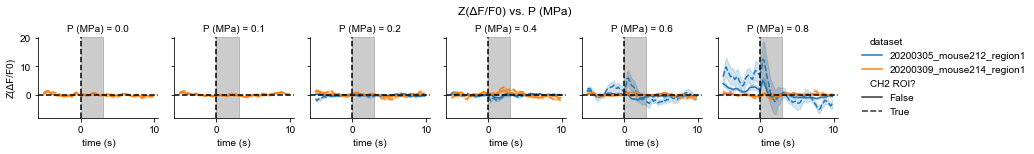

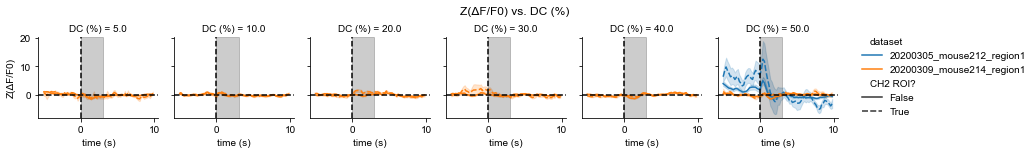

In [24]:
# Facetgrid kwargs
fgkwargs = dict(
    kind='line',
    col_wrap=6,
    height=2,
)

# Compute reference pressure value for duty cycle sweep
p_ref = plt_data[Label.P].max()

# For each input parameter
for xkey in [Label.P, Label.DC]:
    logger.info(f'plotting {ykey_plt} vs. {xkey} response traces...')

    # Plot average traces for each dataset and sweep value
    g = sns.relplot(
        data=get_xdep_data(plt_data, xkey, p_ref=p_ref),
        kind='line',
        x=Label.TIME,
        y=ykey_plt,
        col=xkey,
        hue=Label.DATASET,
        style=Label.CH2_ROI,
        errorbar='se', 
        col_wrap=6,
        height=2,
    )
    
    # Add vertical line at stimulus onset, and horizontal line at 0 
    g.refline(x=0, y=0, c='k')
    for ax in g.axes:
        # print(fidx.get_window_bounds('post'))
        # print(fidx.index_to_time())
        ax.axvspan(0, fidx.npost / fps, color='k', alpha=.2)

    # Add title
    g.fig.suptitle(f'{ykey_plt} vs. {xkey}', y=1.05)
    figs[f'{ykey} resp traces vs. {xkey} ext.'] = g.fig

## Parameter dependency curves

### Compute and plot initial parameter dependency curves with appropriate response window size

In [34]:
fidx.npost = 5

 2025/12/05 16:12:03: applying mean function on Z(ΔF/F0) in [18-26] index window across dataset, ROI, run
 2025/12/05 16:12:03: applying mean function on Z(ΔF/F0) in [26-31] index window across dataset, ROI, run
 2025/12/05 16:12:03: computing evoked Z(ΔF/F0) change...
 2025/12/05 16:12:03: computing ROI-weighted average of (2 datasets x 296 ROIs x 6 runs) "evoked Z(ΔF/F0) change" series across P (MPa)...
 2025/12/05 16:12:04: computing ROI-weighted average of (2 datasets x 53 ROIs x 6 runs) "evoked Z(ΔF/F0) change" series across P (MPa)...
 2025/12/05 16:12:04: computing ROI-weighted average of (2 datasets x 296 ROIs x 7 runs) "evoked Z(ΔF/F0) change" series across DC (%)...
 2025/12/05 16:12:04: computing ROI-weighted average of (2 datasets x 53 ROIs x 7 runs) "evoked Z(ΔF/F0) change" series across DC (%)...
 2025/12/05 16:12:04: adding sample counts per CH2 ROI? on legend labels...


Text(0.5, 1.05, 'evoked response in 1.00s post-stimulus window')

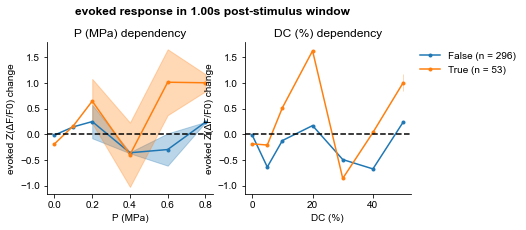

In [35]:
# dep_timeseries, dep_stats = pos_trialagg_timeseries, trialagg_stats
ykey_diff = get_change_key(ykey_plt)
trialagg_stats[ykey_diff] = compute_evoked_change(
    trialagg_timeseries, ykey_plt, fidx)

# Plot evoked response dependency on input parameters
xkeys = [Label.P, Label.DC]
figs['stimparams'] = plot_stimparams_dependency(
    trialagg_stats, 
    ykey_diff,
    xkeys=xkeys,
    # hue=Label.DATASET,
    hue=Label.CH2_ROI,
    errorbar='se',
    marker='.',
)
figs['stimparams'].suptitle(
    f'evoked response in {fidx.npost / fps:.2f}s post-stimulus window', 
    fontsize=12, fontweight='bold', y=1.05)
# figs['stimparams'].subplots_adjust(wspace=.3)


### Examine relationship between "red-cell-status" and evoked response

 2025/12/05 16:11:45: comparing distributions of evoked responses between VIP cells and non-VIP cells...
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

False vs. True: Mann-Whitney-Wilcoxon test two-sided, P_val:1.952e-04 U_stat=7.903e+03


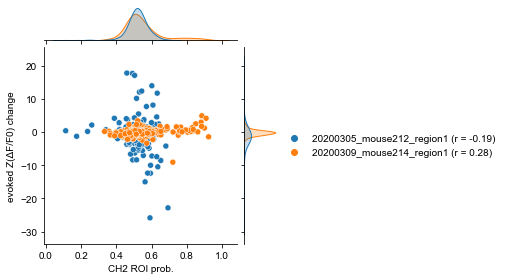

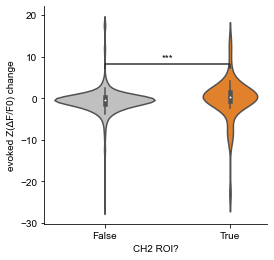

In [33]:
# Compute average evoked response across strong conditions, per ROI
avg_resp = (
    trialagg_stats[trialagg_stats[Label.ISPTA] > ISPTA_THR]
    [ykey_diff]
    .groupby([Label.DATASET, Label.ROI])
    .mean() 
)
df = pd.concat([coreg_stats, avg_resp.to_frame()], axis=1)

# Plot co-distribution of "red-channel" cell probability and evoked response
g = sns.jointplot(
    data=df, 
    x=Label.CH2_ROI_PROB, 
    y=ykey_diff, 
    hue=Label.DATASET,
    kind='scatter', 
    height=4
)

# Add correlation coefficient to legend labels
r = (
    df[[Label.CH2_ROI_PROB, ykey_diff]]
    .groupby(Label.DATASET)
    .corr()
    .iloc[0::2, 1]
    .droplevel(1)
)
rmapper = {k: f'{k} (r = {v:.2f})' for k, v in r.items()}
handles, labels = g.ax_joint.get_legend_handles_labels()
g.ax_joint.legend(
    handles=handles, labels=[rmapper[l] for l in labels],
    loc='center left', bbox_to_anchor=(1.2, 0.5), title=None, frameon=False)

# Compare distributions of evoked responses between red-channel cells and non-red-channel cells
logger.info(f'comparing distributions of evoked responses between {red_channel_key} cells and non-{red_channel_key} cells...')
figs[f'resp strength vs {red_channel_key} status'], ax = plt.subplots(figsize=(4, 4))
sns.despine(ax=ax)
pltkwargs = dict(
    data=df,
    x=Label.CH2_ROI,
    y=ykey_diff,
    palette=Palette.CH2_ROI
)
sns.violinplot(ax=ax, **pltkwargs)
annotator = Annotator(ax, [(False, True)], **pltkwargs)
annotator.configure(test='Mann-Whitney')
annotator.apply_and_annotate();

### Save figures

In [18]:
figs = {k: v for k, v in figs.items() if v is not None}
save_figs_book(figsdir, figs, suffix=figs_suffix)

 2025/11/28 16:42:02: saving figures in /Users/tlemaire/Documents/data/usnm/figs/2025.11.28/figs_main_cre_vip_k0.5_alpha0.7_qadaptive_wq30.0s_aggmedian_classzscore_directional.pdf:


100%|██████████| 12/12 [00:02<00:00,  5.40it/s]


### Notify upon completion

In [20]:
# Get time stamp from notebook completion
tstamp_end = datetime.datetime.now()

# Log completion process
s = f'vip analysis notebook completed in {tstamp_end - tstamp_start} s'
if slack_notify:
    jupyter_slack.notify_self(s)
logger.info(s)

 2025/11/28 16:42:17: vip analysis notebook completed in 0:01:07.626906 s
